# RemBERT 

## Subtask 1 - Polarization detection

This is a binary classification to determine whether a post contains polarized content (Polarized or Not Polarized).

## Imports

In [1]:
import os
print("Current Working Directory:", os.getcwd())
print("\nFiles in this directory:", os.listdir())

Current Working Directory: c:\Users\georg\Desktop\NLP_Proj

Files in this directory: ['.git', '0.15.0', 'EXAMPLE_PAPER', 'Project_Proposal___Intro2NLP__PF___Copy___Copy_.pdf', 'README.md', 'RemBERT.ipynb', 'starter.ipynb', 'subtask1', 'subtask2', 'subtask3']


In [2]:
import pandas as pd

from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import numpy as np

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

import matplotlib.pyplot as plt

W1230 02:31:05.075858 28368 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [3]:
import wandb

# Disable wandb logging for this script
wandb.init(mode="disabled")

In [4]:
# Check GPU availability
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())
else:
    print("Using CPU")

CUDA available: True
GPU name: NVIDIA GeForce RTX 3050 Ti Laptop GPU
GPU count: 1
Current device: 0


## Data Import

The training data consists of a short text and binary labels

The data is structured as a CSV file with the following fields:
- id: a unique identifier for the sample
- text: a sentence or short text
- polarization:  1 text is polarized, 0 text is not polarized

The data is in all three subtask folders the same but only containing the labels for the specific task.

In [5]:
from sklearn.model_selection import train_test_split

# Load the English training data for subtask 1 using RemBERT
train_eng_full = pd.read_csv('subtask1/data/train/eng.csv')

# Split into train and validation
train_eng, val_eng = train_test_split(train_eng_full, test_size=0.2, random_state=42)

# Load the Arabic training data for subtask 1 using RemBERT
train_arb_full = pd.read_csv('subtask1/data/train/arb.csv')

# Split into train and validation
train_arb, val_arb = train_test_split(train_arb_full, test_size=0.2, random_state=42)



In [6]:
train_eng.head()

,id,text,polarization
1920,eng_2f764e2db995e29da3dabee9db02e446,In Gaza there are no Underground Railroads for...,1
2018,eng_ba3420871f1d9f55c1ee48381744ed6a,Not when it comes to the radical left.,1
1029,eng_3885745e6aa811eda4f1ae11108266d8,STOP RUSSIAN AGGRESSION AGAINST UKRAINE. StopP...,0
1621,eng_599cf608885a86719a39232c28af4381,Why didnt Hegseth meet with Democrats?,0
69,eng_4b0f94e8114dea01d392718b9155ffca,All in the Family: Sheriff's Son Is New DPS Of...,0


In [7]:
train_arb.head()

,id,text,polarization
3053,arb_7a9039c2115b8408aa2bb5d95b93e048,٥ دقايق والتعادل السلبي وجانب دفاعي من بتروجيت...,0
2440,arb_70ec85371e45ab3806c3401d14c46dfa,هي زعلت لية مش فاهم \r\nماهي وكل النسوان بيروح...,1
2910,arb_7acb3124eca810f0d40161507f25370f,عايشة الدور مع نفسك كلامي واضح كل حرف و ر...,1
2628,arb_d2e45a95b1500c9b370461aa3f83b0eb,النادي الاهلي يفوز علي نادي الجونه بنتيجة ١١ -...,0
839,arb_43f0ac2a4110dff0edd7c7c3dc6b8684,بعدك بتدور ع الجنسية الاماراتية\r\nع الفاضي ري...,1


## Dataset Visualization for Subtask 1

Let's visualize the distribution of polarization labels and text lengths for both English and Arabic datasets.

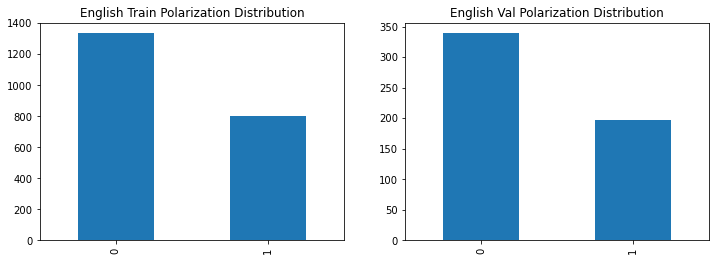

C:\Users\georg\AppData\Local\Temp/ipykernel_28368/1072130183.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_eng['text_length'] = train_eng['text'].apply(len)
C:\Users\georg\AppData\Local\Temp/ipykernel_28368/1072130183.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_eng['text_length'] = val_eng['text'].apply(len)


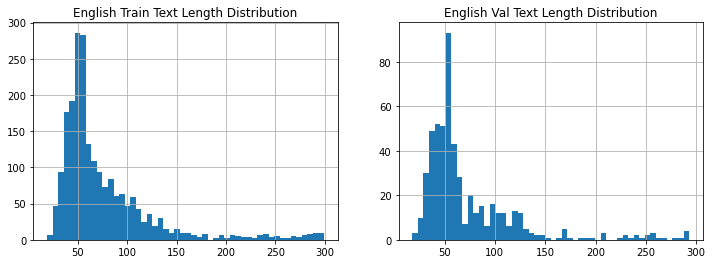

In [8]:
# Visualization for English Subtask 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_eng['polarization'].value_counts().plot(kind='bar', ax=axes[0], title='English Train Polarization Distribution')

val_eng['polarization'].value_counts().plot(kind='bar', ax=axes[1], title='English Val Polarization Distribution')

plt.show()

# Text lengths
train_eng['text_length'] = train_eng['text'].apply(len)
val_eng['text_length'] = val_eng['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))


train_eng['text_length'].hist(ax=axes[0], bins=50)
val_eng['text_length'].hist(ax=axes[1], bins=50)

axes[0].set_title('English Train Text Length Distribution')
axes[1].set_title('English Val Text Length Distribution')

plt.show()

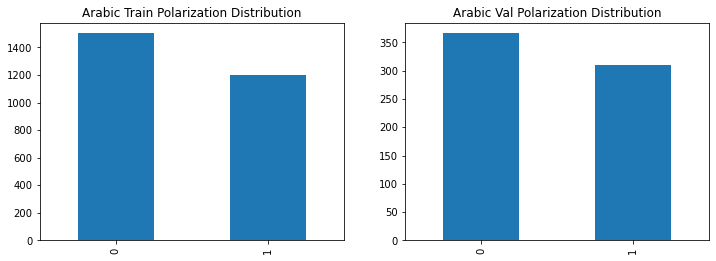

C:\Users\georg\AppData\Local\Temp/ipykernel_28368/578972859.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_arb['text_length'] = train_arb['text'].apply(len)
C:\Users\georg\AppData\Local\Temp/ipykernel_28368/578972859.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_arb['text_length'] = val_arb['text'].apply(len)


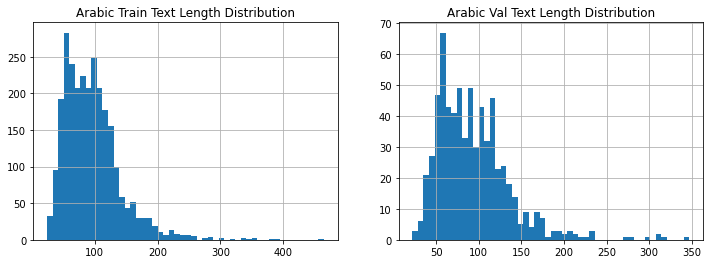

In [9]:
# Visualization for Arabic Subtask 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# The bar plots usually work fine with 'title', so we keep them as is
train_arb['polarization'].value_counts().plot(kind='bar', ax=axes[0], title='Arabic Train Polarization Distribution')
val_arb['polarization'].value_counts().plot(kind='bar', ax=axes[1], title='Arabic Val Polarization Distribution')

plt.show()
# Text lengths

train_arb['text_length'] = train_arb['text'].apply(len)
val_arb['text_length'] = val_arb['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_arb['text_length'].hist(ax=axes[0], bins=50)
val_arb['text_length'].hist(ax=axes[1], bins=50)

axes[0].set_title('Arabic Train Text Length Distribution')
axes[1].set_title('Arabic Val Text Length Distribution')

plt.show()

## English Subtask 1: Polarization Detection

In this section, we prepare and train RemBERT on the English dataset for detecting polarized content.

## Dataset Preparation for English

We create a custom PyTorch dataset class to handle the English texts and labels, preparing them for RemBERT training.

In [10]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
  def __init__(self,texts,labels,tokenizer,max_length =128):
    self.texts=texts
    self.labels=labels
    self.tokenizer= tokenizer
    self.max_length = max_length # Store max_length

  def __len__(self):
    return len(self.texts)

  def __getitem__(self,idx):
    text=self.texts[idx]
    label=self.labels[idx]
    encoding=self.tokenizer(text,truncation=True,padding=False,max_length=self.max_length,return_tensors='pt')

    # Ensure consistent tensor conversion for all items
    item = {key: encoding[key].squeeze() for key in encoding.keys()}
    item['labels'] = torch.tensor(label, dtype=torch.long)
    return item

## Tokenization and Dataset Creation for English

We load the RemBERT tokenizer and create datasets for the English training and validation data.

In [11]:
# Load the tokenizer for English
tokenizer = AutoTokenizer.from_pretrained('google/rembert')

# Create datasets for English
train_dataset = PolarizationDataset(train_eng['text'].tolist(), train_eng['polarization'].tolist(), tokenizer)
val_dataset = PolarizationDataset(val_eng['text'].tolist(), val_eng['polarization'].tolist(), tokenizer)

c:\Users\georg\anaconda3\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## Model Loading for English

We load the pre-trained RemBERT model configured for binary classification on the English dataset.

In [12]:
# Load the model
model = AutoModelForSequenceClassification.from_pretrained('google/rembert', num_labels=2)

Some weights of RemBertForSequenceClassification were not initialized from the model checkpoint at google/rembert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training Configuration for English

We define the training arguments and evaluation metrics for the English RemBERT model.

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'precision_macro': precision_score(labels, preds, average='macro'),
        'recall_macro': recall_score(labels, preds, average='macro')
    }

# Define training arguments
training_args = TrainingArguments(
        output_dir=f"./",
        num_train_epochs=3,
        learning_rate=2e-5,
        per_device_train_batch_size=64,
        per_device_eval_batch_size=8,
        evaluation_strategy="epoch",
        save_strategy="no",
        logging_steps=100,
        disable_tqdm=False
    )

## Training RemBERT on English Subtask 1

We initialize the Trainer and train the RemBERT model on the English dataset.

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=val_dataset,            # evaluation dataset
    compute_metrics=compute_metrics,     # the callback that computes metrics of interest
    data_collator=DataCollatorWithPadding(tokenizer) # Data collator for dynamic padding
)

# Train the model
trainer.train()

# Evaluate the model on the validation set
eval_results = trainer.evaluate()
trainer.save_model("./final_models/task1_english")
print(f"Macro F1 score on validation set: {eval_results['eval_f1_macro']}")

  0%|          | 0/102 [00:00<?, ?it/s]

## Arabic Subtask 1: Polarization Detection

In this section, we prepare and train RemBERT on the Arabic dataset for detecting polarized content.

## Dataset Preparation for Arabic

We create a custom PyTorch dataset class to handle the Arabic texts and labels, preparing them for RemBERT training.

In [ ]:
# Fix the dataset class by inheriting from torch.utils.data.Dataset
class PolarizationDataset(torch.utils.data.Dataset):
  def __init__(self,texts,labels,tokenizer,max_length =128):
    self.texts=texts
    self.labels=labels
    self.tokenizer= tokenizer
    self.max_length = max_length # Store max_length

  def __len__(self):
    return len(self.texts)

  def __getitem__(self,idx):
    text=self.texts[idx]
    label=self.labels[idx]
    encoding=self.tokenizer(text,truncation=True,padding=False,max_length=self.max_length,return_tensors='pt')

    # Ensure consistent tensor conversion for all items
    item = {key: encoding[key].squeeze() for key in encoding.keys()}
    item['labels'] = torch.tensor(label, dtype=torch.long)
    return item

## Tokenization and Dataset Creation for Arabic

We load the RemBERT tokenizer and create datasets for the Arabic training and validation data.

In [ ]:
# Load the tokenizer for Arabic
tokenizer = AutoTokenizer.from_pretrained('google/rembert')

# Create datasets for Arabic
train_dataset = PolarizationDataset(train_arb['text'].tolist(), train_arb['polarization'].tolist(), tokenizer)
val_dataset = PolarizationDataset(val_arb['text'].tolist(), val_arb['polarization'].tolist(), tokenizer)

## Model Loading for Arabic

We load the pre-trained RemBERT model configured for binary classification on the Arabic dataset.

In [ ]:
# Load the model
model = AutoModelForSequenceClassification.from_pretrained('google/rembert', num_labels=2)

## Training Configuration for Arabic

We define the training arguments and evaluation metrics for the Arabic RemBERT model.

In [ ]:
# Define metrics function
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return {'f1_macro': f1_score(p.label_ids, preds, average='macro')}

# Define training arguments
training_args = TrainingArguments(
        output_dir=f"./",
        num_train_epochs=3,
        learning_rate=2e-5,
        per_device_train_batch_size=64,
        per_device_eval_batch_size=8,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=100,
        disable_tqdm=False
    )

## Training RemBERT on Arabic Subtask 1

We initialize the Trainer and train the RemBERT model on the Arabic dataset.

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=val_dataset,            # evaluation dataset
    compute_metrics=compute_metrics,     # the callback that computes metrics of interest
    data_collator=DataCollatorWithPadding(tokenizer) # Data collator for dynamic padding
)

# Train the model
trainer.train()

trainer.save_model("./final_models/task1_arabic")

# Evaluate the model on the validation set
eval_results = trainer.evaluate()
print(f"Macro F1 score on validation set: {eval_results['eval_f1_macro']}")

# Subtask 2: Polarization Type Classification
Multi-label classification to identify the target of polarization as one of the following categories: Gender/Sexual, Political, Religious, Racial/Ethnic, or Other.
For this task we will load the data for subtask 2.

In [ ]:
# Load the English training data for subtask 2 using RemBERT
train_eng_full = pd.read_csv('subtask2/data/train/eng.csv')

# Split into train and validation
train_eng, val_eng = train_test_split(train_eng_full, test_size=0.2, random_state=42)

# Load the Arabic training data for subtask 2 using RemBERT
train_arb_full = pd.read_csv('subtask2/data/train/arb.csv')

# Split into train and validation
train_arb, val_arb = train_test_split(train_arb_full, test_size=0.2, random_state=42)


,id,text,political,racial/ethnic,religious,gender/sexual,other
1920,eng_2f764e2db995e29da3dabee9db02e446,In Gaza there are no Underground Railroads for...,1,1,0,0,0
2018,eng_ba3420871f1d9f55c1ee48381744ed6a,Not when it comes to the radical left.,1,0,0,0,0
1029,eng_3885745e6aa811eda4f1ae11108266d8,STOP RUSSIAN AGGRESSION AGAINST UKRAINE. StopP...,0,0,0,0,0
1621,eng_599cf608885a86719a39232c28af4381,Why didnt Hegseth meet with Democrats?,0,0,0,0,0
69,eng_4b0f94e8114dea01d392718b9155ffca,All in the Family: Sheriff's Son Is New DPS Of...,0,0,0,0,0


In [16]:
train_eng.head()

,id,text,political,racial/ethnic,religious,gender/sexual,other
1920,eng_2f764e2db995e29da3dabee9db02e446,In Gaza there are no Underground Railroads for...,1,1,0,0,0
2018,eng_ba3420871f1d9f55c1ee48381744ed6a,Not when it comes to the radical left.,1,0,0,0,0
1029,eng_3885745e6aa811eda4f1ae11108266d8,STOP RUSSIAN AGGRESSION AGAINST UKRAINE. StopP...,0,0,0,0,0
1621,eng_599cf608885a86719a39232c28af4381,Why didnt Hegseth meet with Democrats?,0,0,0,0,0
69,eng_4b0f94e8114dea01d392718b9155ffca,All in the Family: Sheriff's Son Is New DPS Of...,0,0,0,0,0


In [17]:
train_arb.head()

,id,text,political,racial/ethnic,religious,gender/sexual,other
3053,arb_7a9039c2115b8408aa2bb5d95b93e048,٥ دقايق والتعادل السلبي وجانب دفاعي من بتروجيت...,0,0,0,0,0
2440,arb_70ec85371e45ab3806c3401d14c46dfa,هي زعلت لية مش فاهم \r\nماهي وكل النسوان بيروح...,0,0,0,1,0
2910,arb_7acb3124eca810f0d40161507f25370f,عايشة الدور مع نفسك كلامي واضح كل حرف و ر...,0,0,1,0,0
2628,arb_d2e45a95b1500c9b370461aa3f83b0eb,النادي الاهلي يفوز علي نادي الجونه بنتيجة ١١ -...,0,0,0,0,0
839,arb_43f0ac2a4110dff0edd7c7c3dc6b8684,بعدك بتدور ع الجنسية الاماراتية\r\nع الفاضي ري...,0,1,0,0,0


## Dataset Visualization for Subtask 2

Visualizing the label distributions for polarization types in English and Arabic datasets.

In [ ]:
# Visualization for English Subtask 2

labels = ['political', 'racial/ethnic', 'religious', 'gender/sexual', 'other']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

train_eng[labels].sum().plot(kind='bar', ax=axes[0], title='English Train Label Distribution')

val_eng[labels].sum().plot(kind='bar', ax=axes[1], title='English Val Label Distribution')

plt.show()

# Text lengths

train_eng['text_length'] = train_eng['text'].apply(len)

val_eng['text_length'] = val_eng['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_eng['text_length'].hist(ax=axes[0], bins=50, title='English Train Text Length Distribution')

val_eng['text_length'].hist(ax=axes[1], bins=50, title='English Val Text Length Distribution')

plt.show()

In [ ]:
# Visualization for Arabic Subtask 2

labels = ['political', 'racial/ethnic', 'religious', 'gender/sexual', 'other']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

train_arb[labels].sum().plot(kind='bar', ax=axes[0], title='Arabic Train Label Distribution')

val_arb[labels].sum().plot(kind='bar', ax=axes[1], title='Arabic Val Label Distribution')

plt.show()

# Text lengths

train_arb['text_length'] = train_arb['text'].apply(len)

val_arb['text_length'] = val_arb['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_arb['text_length'].hist(ax=axes[0], bins=50, title='Arabic Train Text Length Distribution')

val_arb['text_length'].hist(ax=axes[1], bins=50, title='Arabic Val Text Length Distribution')

plt.show()

## English Subtask 2: Polarization Type Classification

In this section, we prepare and train RemBERT on the English dataset for classifying polarization types.

In [ ]:
# Define the dataset class for multi-label classification in English
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [14]:
# Load the tokenizer for English subtask 2
tokenizer = AutoTokenizer.from_pretrained('google/rembert')

# Create train and Test dataset for multilabel English
train_dataset = PolarizationDataset(train_eng['text'].tolist(), train_eng[['political','racial/ethnic','religious','gender/sexual','other']].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val_eng['text'].tolist(), val_eng[['political','racial/ethnic','religious','gender/sexual','other']].values.tolist(), tokenizer)
dev_dataset = PolarizationDataset(val_eng['text'].tolist(), val_eng[['political','racial/ethnic','religious','gender/sexual','other']].values.tolist(), tokenizer)

NameError: name 'AutoTokenizer' is not defined

In [ ]:
# Load the model
model = AutoModelForSequenceClassification.from_pretrained('google/rembert', num_labels=5, problem_type="multi_label_classification") # 5 labels

In [ ]:
# Define metrics function for multi-label classification
def compute_metrics_multilabel(p):
    # Sigmoid the predictions to get probabilities
    probs = torch.sigmoid(torch.from_numpy(p.predictions))
    # Convert probabilities to predicted labels (0 or 1)
    preds = (probs > 0.5).int().numpy()
    # Compute macro F1 score
    return {'f1_macro': f1_score(p.label_ids, preds, average='macro')}

# Define training arguments
training_args = TrainingArguments(
    output_dir=f"./",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=100,
    disable_tqdm=False
)

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_multilabel,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer)
)

# Train the model
trainer.train()
trainer.save_model("./final_models/task2_english")

# Evaluate the model on the validation set
eval_results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 2: {eval_results['eval_f1_macro']}")

## Arabic Subtask 2: Polarization Type Classification

In this section, we prepare and train RemBERT on the Arabic dataset for classifying polarization types.

In [ ]:
# Define the dataset class for multi-label classification in Arabic
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer for Arabic subtask 2
tokenizer = AutoTokenizer.from_pretrained('google/rembert')

# Create train and Test dataset for multilabel Arabic
train_dataset = PolarizationDataset(train_arb['text'].tolist(), train_arb[['political','racial/ethnic','religious','gender/sexual','other']].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val_arb['text'].tolist(), val_arb[['political','racial/ethnic','religious','gender/sexual','other']].values.tolist(), tokenizer)
dev_dataset = PolarizationDataset(val_arb['text'].tolist(), val_arb[['political','racial/ethnic','religious','gender/sexual','other']].values.tolist(), tokenizer)

In [ ]:
# Load the model
model = AutoModelForSequenceClassification.from_pretrained('google/rembert', num_labels=5, problem_type="multi_label_classification") # 5 labels

In [ ]:
# Define metrics function for multi-label classification
def compute_metrics_multilabel(p):
    # Sigmoid the predictions to get probabilities
    probs = torch.sigmoid(torch.from_numpy(p.predictions))
    # Convert probabilities to predicted labels (0 or 1)
    preds = (probs > 0.5).int().numpy()
    # Compute macro F1 score
    return {'f1_macro': f1_score(p.label_ids, preds, average='macro')}

# Define training arguments
training_args = TrainingArguments(
    output_dir=f"./",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=100,
    disable_tqdm=False
)

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_multilabel,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer)
)

# Train the model
trainer.train()
trainer.save_model("./final_models/task2_arabic")
# Evaluate the model on the validation set
eval_results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 2: {eval_results['eval_f1_macro']}")

# Subtask 3: Manifestation Identification

Multi-label classification to classify how polarization is expressed, with multiple possible labels including Vilification, Extreme Language, Stereotype, Invalidation, Lack of Empathy, and Dehumanization.

In [18]:
# Load the English training data for subtask 3 using RemBERT
train_eng_full = pd.read_csv('subtask3/data/train/eng.csv')

# Split into train and validation
train_eng, val_eng = train_test_split(train_eng_full, test_size=0.2, random_state=42)

# Load the Arabic training data for subtask 3 using RemBERT
train_arb_full = pd.read_csv('subtask3/data/train/arb.csv')

# Split into train and validation
train_arb, val_arb = train_test_split(train_arb_full, test_size=0.2, random_state=42)

train_eng.head()

,id,text,stereotype,vilification,dehumanization,extreme_language,lack_of_empathy,invalidation
1920,eng_2f764e2db995e29da3dabee9db02e446,In Gaza there are no Underground Railroads for...,0,1,0,0,1,1
2018,eng_ba3420871f1d9f55c1ee48381744ed6a,Not when it comes to the radical left.,1,1,1,1,0,0
1029,eng_3885745e6aa811eda4f1ae11108266d8,STOP RUSSIAN AGGRESSION AGAINST UKRAINE. StopP...,0,0,0,0,0,0
1621,eng_599cf608885a86719a39232c28af4381,Why didnt Hegseth meet with Democrats?,0,0,0,0,0,0
69,eng_4b0f94e8114dea01d392718b9155ffca,All in the Family: Sheriff's Son Is New DPS Of...,0,0,0,0,0,0


In [19]:
train_eng.head()

,id,text,stereotype,vilification,dehumanization,extreme_language,lack_of_empathy,invalidation
1920,eng_2f764e2db995e29da3dabee9db02e446,In Gaza there are no Underground Railroads for...,0,1,0,0,1,1
2018,eng_ba3420871f1d9f55c1ee48381744ed6a,Not when it comes to the radical left.,1,1,1,1,0,0
1029,eng_3885745e6aa811eda4f1ae11108266d8,STOP RUSSIAN AGGRESSION AGAINST UKRAINE. StopP...,0,0,0,0,0,0
1621,eng_599cf608885a86719a39232c28af4381,Why didnt Hegseth meet with Democrats?,0,0,0,0,0,0
69,eng_4b0f94e8114dea01d392718b9155ffca,All in the Family: Sheriff's Son Is New DPS Of...,0,0,0,0,0,0


In [20]:
train_arb.head()

,id,text,stereotype,vilification,dehumanization,extreme_language,lack_of_empathy,invalidation
3053,arb_7a9039c2115b8408aa2bb5d95b93e048,٥ دقايق والتعادل السلبي وجانب دفاعي من بتروجيت...,0,0,0,0,0,0
2440,arb_70ec85371e45ab3806c3401d14c46dfa,هي زعلت لية مش فاهم \r\nماهي وكل النسوان بيروح...,1,1,0,1,1,0
2910,arb_7acb3124eca810f0d40161507f25370f,عايشة الدور مع نفسك كلامي واضح كل حرف و ر...,1,0,0,1,0,0
2628,arb_d2e45a95b1500c9b370461aa3f83b0eb,النادي الاهلي يفوز علي نادي الجونه بنتيجة ١١ -...,0,0,0,0,0,0
839,arb_43f0ac2a4110dff0edd7c7c3dc6b8684,بعدك بتدور ع الجنسية الاماراتية\r\nع الفاضي ري...,1,1,0,0,1,0


## Dataset Visualization for Subtask 3

Visualizing the label distributions for polarization manifestations in English and Arabic datasets.

In [ ]:
# Visualization for English Subtask 3

labels = ['stereotype', 'vilification', 'dehumanization', 'extreme_language', 'lack_of_empathy', 'invalidation']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

train_eng[labels].sum().plot(kind='bar', ax=axes[0], title='English Train Label Distribution')

val_eng[labels].sum().plot(kind='bar', ax=axes[1], title='English Val Label Distribution')

plt.show()

# Text lengths

train_eng['text_length'] = train_eng['text'].apply(len)

val_eng['text_length'] = val_eng['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_eng['text_length'].hist(ax=axes[0], bins=50, title='English Train Text Length Distribution')

val_eng['text_length'].hist(ax=axes[1], bins=50, title='English Val Text Length Distribution')

plt.show()

In [ ]:
# Visualization for Arabic Subtask 3

labels = ['stereotype', 'vilification', 'dehumanization', 'extreme_language', 'lack_of_empathy', 'invalidation']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

train_arb[labels].sum().plot(kind='bar', ax=axes[0], title='Arabic Train Label Distribution')

val_arb[labels].sum().plot(kind='bar', ax=axes[1], title='Arabic Val Label Distribution')

plt.show()

# Text lengths

train_arb['text_length'] = train_arb['text'].apply(len)

val_arb['text_length'] = val_arb['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_arb['text_length'].hist(ax=axes[0], bins=50, title='Arabic Train Text Length Distribution')

val_arb['text_length'].hist(ax=axes[1], bins=50, title='Arabic Val Text Length Distribution')

plt.show()

## English Subtask 3: Manifestation Identification

In this section, we prepare and train RemBERT on the English dataset for identifying polarization manifestations.

In [ ]:
# Define the dataset class for multi-label classification in English subtask 3
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer for English subtask 3
tokenizer = AutoTokenizer.from_pretrained('google/rembert')

# Create train and Test dataset for multilabel English
train_dataset = PolarizationDataset(train_eng['text'].tolist(), train_eng[['stereotype','vilification','dehumanization','extreme_language','lack_of_empathy','invalidation']].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val_eng['text'].tolist(), val_eng[['stereotype','vilification','dehumanization','extreme_language','lack_of_empathy','invalidation']].values.tolist(), tokenizer)

In [ ]:
# Load the model
model = AutoModelForSequenceClassification.from_pretrained('google/rembert', num_labels=6, problem_type="multi_label_classification") # use 6 labels

In [ ]:
# Define training arguments
training_args = TrainingArguments(
    output_dir=f"./",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=100,
    disable_tqdm=False
)

# Define metrics function for multi-label classification
def compute_metrics_multilabel(p):
    # Sigmoid the predictions to get probabilities
    probs = torch.sigmoid(torch.from_numpy(p.predictions))
    # Convert probabilities to predicted labels (0 or 1)
    preds = (probs > 0.5).int().numpy()
    # Compute macro F1 score
    return {'f1_macro': f1_score(p.label_ids, preds, average='macro')}

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_multilabel,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer)
)

# Train the model
trainer.train()

# Evaluate the model on the validation set
eval_results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {eval_results['eval_f1_macro']}")

## Arabic Subtask 3: Manifestation Identification

In this section, we prepare and train RemBERT on the Arabic dataset for identifying polarization manifestations.

In [ ]:
# Define the dataset class for multi-label classification in Arabic subtask 3
class PolarizationDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length # Store max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, truncation=True, padding=False, max_length=self.max_length, return_tensors='pt')

        # Ensure consistent tensor conversion for all items
        item = {key: encoding[key].squeeze() for key in encoding.keys()}
        # CHANGE THIS LINE: Use torch.float instead of torch.long for multi-label classification
        item['labels'] = torch.tensor(label, dtype=torch.float)
        return item

In [ ]:
# Load the tokenizer for Arabic subtask 3
tokenizer = AutoTokenizer.from_pretrained('google/rembert')

# Create train and Test dataset for multilabel Arabic
train_dataset = PolarizationDataset(train_arb['text'].tolist(), train_arb[['stereotype','vilification','dehumanization','extreme_language','lack_of_empathy','invalidation']].values.tolist(), tokenizer)
val_dataset = PolarizationDataset(val_arb['text'].tolist(), val_arb[['stereotype','vilification','dehumanization','extreme_language','lack_of_empathy','invalidation']].values.tolist(), tokenizer)

In [ ]:
# Load the model
model = AutoModelForSequenceClassification.from_pretrained('google/rembert', num_labels=6, problem_type="multi_label_classification") # use 6 labels

In [ ]:
# Define training arguments
training_args = TrainingArguments(
    output_dir=f"./",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=100,
    disable_tqdm=False
)

# Define metrics function for multi-label classification
def compute_metrics_multilabel(p):
    # Sigmoid the predictions to get probabilities
    probs = torch.sigmoid(torch.from_numpy(p.predictions))
    # Convert probabilities to predicted labels (0 or 1)
    preds = (probs > 0.5).int().numpy()
    # Compute macro F1 score
    return {'f1_macro': f1_score(p.label_ids, preds, average='macro')}

In [ ]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_multilabel,  # Use the new metrics function
    data_collator=DataCollatorWithPadding(tokenizer)
)

# Train the model
trainer.train()

# Evaluate the model on the validation set
eval_results = trainer.evaluate()
print(f"Macro F1 score on validation set for Subtask 3: {eval_results['eval_f1_macro']}")